# Versión en Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'transformers', 'accelerate', 'soundfile'], check=True)
print('✓ Dependencias instaladas')

✓ Dependencias instaladas


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import IPython.display as ipd

DEVICE = torch.device('cuda')
print(f'✓ Dispositivo: {DEVICE}')

PROJECT_DIR = Path("/content/drive/MyDrive/DEEP/gan_project")
LJS_DIR     = PROJECT_DIR / 'data' / 'raw' / 'LJSpeech-1.1'
print(f'✓ Datos: {LJS_DIR}')

✓ Dispositivo: cuda
✓ Datos: /content/drive/MyDrive/DEEP/gan_project/data/raw/LJSpeech-1.1


In [4]:
from transformers import VitsModel, VitsTokenizer

MODEL_ID  = 'facebook/mms-tts-eng'
tokenizer = VitsTokenizer.from_pretrained(MODEL_ID)
model     = VitsModel.from_pretrained(MODEL_ID).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
SR = model.config.sampling_rate
print(f'✓ Modelo cargado: {MODEL_ID}')
print(f'  Parámetros: {total_params:.1f}M | sample_rate: {SR} Hz')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

✓ Modelo cargado: facebook/mms-tts-eng
  Parámetros: 36.3M | sample_rate: 16000 Hz


In [5]:
# ── Prueba de inferencia con el modelo pre-entrenado ──────────────────────────
test_text = 'Printing, in the only sense with which we are at present concerned.'

inputs = tokenizer(test_text, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    output = model(**inputs)

wav_np = output.waveform[0].cpu().numpy()

sf.write('pretrained_sample.wav', wav_np, SR)
print(f'✓ Audio pre-entrenado: {len(wav_np)/SR:.2f}s')
ipd.display(ipd.Audio(wav_np, rate=SR))

✓ Audio pre-entrenado: 4.43s


In [6]:
class LJSpeechDataset(Dataset):
    def __init__(self, metadata_path, wav_dir, tokenizer, target_sr=16000, max_samples=None):
        # cargar metadatos desde el CSV
        df = pd.read_csv(metadata_path, sep='|', header=None, quoting=3)
        df.columns = ['id', 'transcription', 'normalized']

        # limitar muestras si se solicita
        if max_samples:
            df = df.head(max_samples)

        self.data = df
        self.wav_dir = Path(wav_dir)
        self.tokenizer = tokenizer
        self.target_sr = target_sr

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row      = self.data.iloc[idx]
        text     = str(row['normalized']).strip()
        wav_path = self.wav_dir / f"{row['id']}.wav"

        # cargar audio
        wav_np, sr = sf.read(wav_path, dtype='float32')

        # convertir a mono si es necesario
        if wav_np.ndim > 1:
            wav_np = wav_np.mean(axis=1)

        # remuestreo (si el audio original (sr) no es 16000, lo cambiamos)
        if sr != self.target_sr:
            wav_np = librosa.resample(wav_np, orig_sr=sr, target_sr=self.target_sr)

        wav = torch.from_numpy(wav_np)

        # tokenización del texto
        tokens = self.tokenizer(text, return_tensors='pt')

        return (tokens['input_ids'].squeeze(0),
                tokens['attention_mask'].squeeze(0),
                wav)

def collate_fn(batch):
    """ Función para unificar los tamaños de texto y audio en cada batch """
    ids_list, attn_list, wav_list = zip(*batch)

    # padding de texto
    max_text = max(x.shape[0] for x in ids_list)
    ids_pad  = torch.zeros(len(batch), max_text, dtype=torch.long)
    attn_pad = torch.zeros(len(batch), max_text, dtype=torch.long)

    # padding de audio (wav)
    max_wav  = max(w.shape[0] for w in wav_list)
    wav_pad  = torch.zeros(len(batch), max_wav)

    for i, (ids, attn, wav) in enumerate(zip(ids_list, attn_list, wav_list)):
        ids_pad[i,  :ids.shape[0]]  = ids
        attn_pad[i, :attn.shape[0]] = attn
        wav_pad[i,  :wav.shape[0]]  = wav

    return ids_pad, attn_pad, wav_pad

# --- CONFIGURACIÓN Y CARGA ---

MAX_TRAIN  = 8
BATCH_SIZE = 2
SR_MODEL   = 16000 # el modelo MMS de Facebook siempre usa 16kHz

# instanciar el dataset con los parámetros correctos
dataset = LJSpeechDataset(
    metadata_path = LJS_DIR / 'metadata.csv',
    wav_dir       = LJS_DIR / 'wavs',
    tokenizer     = tokenizer,
    target_sr     = SR_MODEL,
    max_samples   = MAX_TRAIN,
)

# división de train y test (90% / 10%)
n_val   = max(1, int(len(dataset) * 0.1))
n_train = len(dataset) - n_val

train_set, val_set = torch.utils.data.random_split(
    dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)

# dataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f'✓ Dataset cargado con éxito.')
print(f'✓ Train: {len(train_set)} muestras | {len(train_loader)} batches')
print(f'✓ Val:   {len(val_set)}  muestras | {len(val_loader)} batches')

✓ Dataset cargado con éxito.
✓ Train: 7 muestras | 4 batches
✓ Val:   1  muestras | 1 batches


In [7]:
# ── Mel-loss usando librosa (sin torchaudio) ──────────────────────────────────
mel_fb_np = librosa.filters.mel(sr=SR, n_fft=1024, n_mels=80)
mel_fb    = torch.from_numpy(mel_fb_np).float().to(DEVICE)  # (80, 513)
window    = torch.hann_window(1024).to(DEVICE)

def wav_to_mel(wav):
    """Calcula mel-spectrogram en torch puro (sin torchaudio)."""
    stft = torch.stft(wav, n_fft=1024, hop_length=256, win_length=1024,
                      window=window, return_complex=True)
    mag  = stft.abs()                          # (B, freq, T)
    mel  = torch.matmul(mel_fb, mag)           # (B, 80, T)
    return torch.log(mel.clamp(min=1e-5))

def mel_loss(wav_pred, wav_target):
    min_len    = min(wav_pred.shape[-1], wav_target.shape[-1])
    mel_pred   = wav_to_mel(wav_pred[..., :min_len])
    mel_target = wav_to_mel(wav_target[..., :min_len])
    return F.l1_loss(mel_pred, mel_target)


# solo entrenar decoder y flow (fine-tuning eficiente)
for name, param in model.named_parameters():
    param.requires_grad = ('decoder' in name or 'flow' in name)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'✓ Parámetros entrenables: {trainable:.1f}M (decoder + flow)')

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
print('✓ Optimizer AdamW | lr=1e-4')

✓ Parámetros entrenables: 22.4M (decoder + flow)
✓ Optimizer AdamW | lr=1e-4


Epoch 01/120 | train_loss=3.0522  val_loss=2.2257


Epoch 02/120 | train_loss=2.5894  val_loss=2.3430


Epoch 03/120 | train_loss=2.3831  val_loss=2.3104


Epoch 04/120 | train_loss=2.5308  val_loss=2.1237


Epoch 05/120 | train_loss=2.4273  val_loss=2.1609


...

Epoch 118/120 | train_loss=1.6394  val_loss=1.5655


Epoch 119/120 | train_loss=1.6488  val_loss=1.5117


Epoch 120/120 | train_loss=1.6937  val_loss=1.5618


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Checkpoint guardado: epoch120


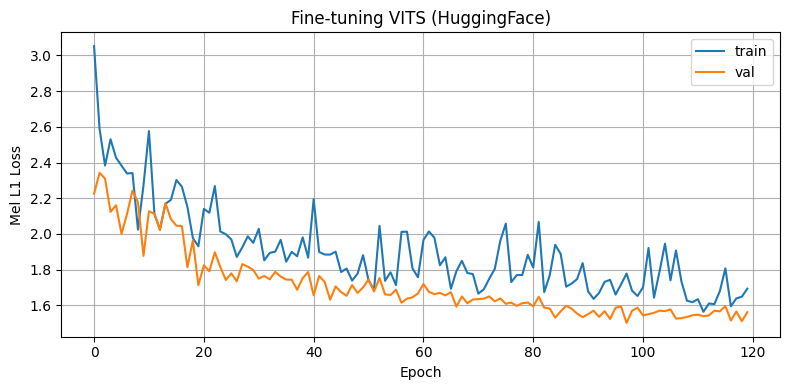

✓ Fine-tuning completado


In [8]:
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints_hf'
CHECKPOINT_DIR.mkdir(exist_ok=True)

N_EPOCHS   = 120
SAVE_EVERY = 8
history    = {'train': [], 'val': []}

accumulation_steps = 4  # batch real 2 * 4 = 8

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    # reiniciamos gradientes al inicio de la época
    optimizer.zero_grad()

    for i, (input_ids, attn_mask, wav_target) in enumerate(tqdm(train_loader,
                                                              desc=f'Epoch {epoch:02d} train',
                                                              leave=False)):
        input_ids  = input_ids.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        wav_target = wav_target.to(DEVICE)

        # forward pass
        output   = model(input_ids=input_ids, attention_mask=attn_mask)
        wav_pred = output.waveform

        # calculamos la pérdida y la normalizamos
        loss = mel_loss(wav_pred, wav_target)
        loss = loss / accumulation_steps

        # backward pass (acumula gradientes, no los borra)
        loss.backward()

        # actualización cada 'accumulation_steps'
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            # clip de gradientes para evitar explosiones
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )

            optimizer.step()     # actualizar pesos
            optimizer.zero_grad() # limpiar gradientes para el siguiente grupo

        train_losses.append(loss.item() * accumulation_steps) # guardamos la loss real

    # ── Validación ────────────────────────────────────────────────────────────
    model.eval()
    val_losses = []
    with torch.no_grad():
        for input_ids, attn_mask, wav_target in val_loader:
            output = model(input_ids=input_ids.to(DEVICE),
                           attention_mask=attn_mask.to(DEVICE))
            v_loss = mel_loss(output.waveform, wav_target.to(DEVICE))
            val_losses.append(v_loss.item())

    # el scheduler normalmente se actualiza por época
    scheduler.step()

    avg_train = np.mean(train_losses)
    avg_val   = np.mean(val_losses)
    history['train'].append(avg_train)
    history['val'].append(avg_val)

    print(f'Epoch {epoch:02d}/{N_EPOCHS} | train_loss={avg_train:.4f}  val_loss={avg_val:.4f}')

    # Guardado de seguridad
    if epoch % SAVE_EVERY == 0:
        model.save_pretrained(str(CHECKPOINT_DIR / f'epoch{epoch:03d}'))
        print(f'  → Checkpoint guardado: epoch{epoch:03d}')

# ── Curva de pérdidas ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='train')
plt.plot(history['val'],   label='val')
plt.xlabel('Epoch'); plt.ylabel('Mel L1 Loss')
plt.title('Fine-tuning VITS (HuggingFace)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()
print('✓ Fine-tuning completado')

In [9]:
# ── Síntesis final con el modelo fine-tuneado ─────────────────────────────────
model.eval()
eval_texts = [
    'Printing, in the only sense with which we are at present concerned.',
    'Hello! This is a text to speech synthesis test after fine-tuning.',
]

for i, text in enumerate(eval_texts):
    print(f'\nTexto: "{text[:70]}"')
    inputs = tokenizer(text, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        wav_np = model(**inputs).waveform[0].cpu().numpy()

    out_path = f'finetuned_sample_{i+1}.wav'
    sf.write(out_path, wav_np, SR)
    print(f'  ✓ Guardado: {out_path} ({len(wav_np)/SR:.2f}s)')
    ipd.display(ipd.Audio(wav_np, rate=SR))


Texto: "Printing, in the only sense with which we are at present concerned."
  ✓ Guardado: finetuned_sample_1.wav (4.53s)



Texto: "Hello! This is a text to speech synthesis test after fine-tuning."
  ✓ Guardado: finetuned_sample_2.wav (4.22s)


In [10]:
# ── Síntesis final con normalización ──────────────────────────────────────────
model.eval()
eval_texts = [
    'Printing, in the only sense with which we are at present concerned.',
    'Hello! This is a text to speech synthesis test after fine-tuning.',
]

print(f"Iniciando síntesis con normalización de picos...")

for i, text in enumerate(eval_texts):
    print(f'\nTexto: "{text[:70]}"...')
    inputs = tokenizer(text.lower(), return_tensors='pt').to(DEVICE) # .lower() ayuda a la estabilidad

    with torch.no_grad():
        # Obtenemos el audio del modelo
        wav_np = model(**inputs).waveform[0].cpu().numpy()

    # PASO DE NORMALIZACIÓN (Peak Normalization)
    # uscamos el valor máximo absoluto para escalar la onda al límite (0.95 para evitar clipping)
    max_amp = np.max(np.abs(wav_np))
    if max_amp > 0:
        wav_np = wav_np / max_amp * 0.95
        print(f"Amplitud normalizada (Factor de escala: {1/max_amp:.2f}x)")
    else:
        print("El audio generado está en silencio.")

    out_path = f'finetuned_sample_{i+4}.wav'
    sf.write(out_path, wav_np, SR)

    print(f'  ✓ Guardado: {out_path} ({len(wav_np)/SR:.2f}s)')
    ipd.display(ipd.Audio(wav_np, rate=SR))

🚀 Iniciando síntesis con normalización de picos...

Texto: "Printing, in the only sense with which we are at present concerned."...
  ⚡ Amplitud normalizada (Factor de escala: 4.50x)
  ✓ Guardado: finetuned_sample_4.wav (4.53s)



Texto: "Hello! This is a text to speech synthesis test after fine-tuning."...
  ⚡ Amplitud normalizada (Factor de escala: 3.92x)
  ✓ Guardado: finetuned_sample_5.wav (4.58s)


In [32]:
import IPython.display as ipd

# texto de prueba
texto_prueba = "wwatch out for men in general"
inputs = tokenizer(texto_prueba.lower(), return_tensors="pt").to(DEVICE)

# generar audio
model.eval()
with torch.no_grad():
    # el modelo VITS de HF devuelve un objeto con la waveform
    outputs = model(**inputs)
    audio_output = outputs.waveform.cpu().numpy().squeeze()

# ver estadísticas del audio generado
print(f"Valor máximo: {audio_output.max()}")
print(f"Valor mínimo: {audio_output.min()}")
print(f"Promedio: {audio_output.mean()}")

# lo normal es que el valor maximo esté entre -1.0 y 1.0

ipd.Audio(audio_output, rate=16000)

Valor máximo: 0.22290828824043274
Valor mínimo: -0.1714848130941391
Promedio: -6.213859160197899e-05
